In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load and resize image to 256x256
image_path = '../../input.jpg'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print("Error: Could not load image")
else:
    sample_image = cv2.resize(original_image, (256, 256))
    print("Image loaded and resized to 256x256")

Image loaded and resized to 256x256


In [3]:
# Function to apply DFT filtering
def dft_filter(image, filter_mask):
    F = np.fft.fft2(image)
    F_shifted = np.fft.fftshift(F)
    G_shifted = F_shifted * filter_mask
    G = np.fft.ifftshift(G_shifted)
    g = np.fft.ifft2(G)
    filtered = np.abs(g)
    return filtered.astype(np.uint8)

# Ideal High-Pass Filter
def ideal_highpass(shape, cutoff):
    H_lp = ideal_lowpass(shape, cutoff)
    return 1 - H_lp

# Butterworth High-Pass Filter
def butterworth_highpass(shape, cutoff, order=2):
    H_lp = butterworth_lowpass(shape, cutoff, order)
    return 1 - H_lp

# Gaussian High-Pass Filter
def gaussian_highpass(shape, cutoff):
    H_lp = gaussian_lowpass(shape, cutoff)
    return 1 - H_lp

# Low-pass functions (same as before)
def ideal_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt((u - crow)**2 + (v - ccol)**2)
    H = (D <= cutoff).astype(np.float32)
    return H

def butterworth_lowpass(shape, cutoff, order=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt((u - crow)**2 + (v - ccol)**2)
    H = 1 / (1 + (D / cutoff)**(2 * order))
    return H

def gaussian_lowpass(shape, cutoff):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(rows)
    v = np.arange(cols)
    u, v = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt((u - crow)**2 + (v - ccol)**2)
    H = np.exp(-D**2 / (2 * cutoff**2))
    return H

In [4]:
# Apply various high-pass filters
cutoff = 30

ideal_hp_filter = ideal_highpass((256, 256), cutoff)
butter_hp_filter = butterworth_highpass((256, 256), cutoff)
gauss_hp_filter = gaussian_highpass((256, 256), cutoff)

ideal_hp_filtered = dft_filter(sample_image, ideal_hp_filter)
butter_hp_filtered = dft_filter(sample_image, butter_hp_filter)
gauss_hp_filtered = dft_filter(sample_image, gauss_hp_filter)

print("High-pass filters applied")

High-pass filters applied


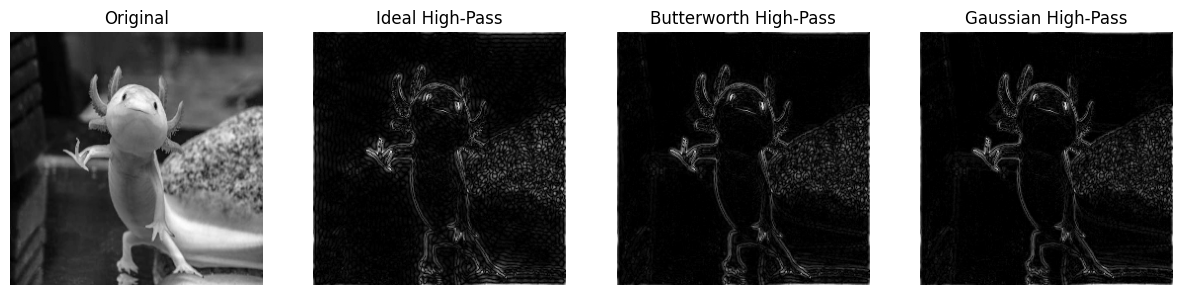

In [5]:
# Display results
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(sample_image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(ideal_hp_filtered, cmap='gray')
plt.title('Ideal High-Pass')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(butter_hp_filtered, cmap='gray')
plt.title('Butterworth High-Pass')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(gauss_hp_filtered, cmap='gray')
plt.title('Gaussian High-Pass')
plt.axis('off')

plt.show()